In [1]:
#import the necessary libraries
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
import re
import pandas as pd
import requests
import time

In [2]:
# !pip install selenium
# !pip install webdriver_manager
# !pip install seleniumwire

In [5]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

chrome_options = Options()
chrome_options.add_argument('--no-sandbox')
chrome_options.add_argument('--disable-dev-shm-usage')
# chrome_options.add_argument('--headless=new')

# 🧠 Pretend to be a real browser (desktop user)
chrome_options.add_argument(
    "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
    "(KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36"
)

# 🕵️ Hide Selenium fingerprinting
chrome_options.add_argument("--disable-blink-features=AutomationControlled")
chrome_options.add_experimental_option("excludeSwitches", ["enable-automation"])
chrome_options.add_experimental_option("useAutomationExtension", False)

# Launch driver
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)

# 🧼 Remove 'webdriver' property (many sites check this)
driver.execute_cdp_cmd("Page.addScriptToEvaluateOnNewDocument", {
    "source": """
        Object.defineProperty(navigator, 'webdriver', {
          get: () => undefined
        })
    """
})

# 🔄 Load page and wait until a key element is visible
# driver.get('https://www.fotmob.com/en-GB/leagues/113/overview/league')

# 🕒 WebDriverWait: Wait up to 10 sec for page element to load (mimics human-like delay)
# WebDriverWait(driver, 10).until(
#     EC.presence_of_element_located((By.CSS_SELECTOR, 'h2'))  # Example element to wait for
# )

{'identifier': '2'}

In [7]:
# === Storage ===
team_a_list = []
team_b_list = []
score_a_list = []
score_b_list = []
match_id_list = []
# === Start looping pages ===
page = 0
try:
    while True:
        url = f'https://www.fotmob.com/en-GB/leagues/113/matches/league?group=by-date&page={page}'
        print(url)
        driver.get(url)
        time.sleep(2)
        
        match_elements = driver.find_elements(By.CSS_SELECTOR, 'a[class*="MatchWrapper"]')
        if not match_elements:
            print(f"No matches found on page {page}. Stopping.")
            break
        
        for match in match_elements:
            text = match.text.strip()
            lines = text.split('\n')
            if len(lines) >= 4:
                team_a = lines[0]
                score = lines[2]
                team_b = lines[3]
             
                # Handle scores safely
                if ' - ' in score:
                    score_a, score_b = score.split(' - ')
                else:
                    score_a, score_b = None, None
                match_id = match.get_attribute("href").split("#")[-1]
                # Append data
                team_a_list.append(team_a)
                team_b_list.append(team_b)
                score_a_list.append(score_a)
                score_b_list.append(score_b)
                match_id_list.append(match_id)
            else:
                print(f"Unexpected match format detected: {text}")
                raise ValueError("Match format changed - stopping script")
                
        print(f"✅ Page {page} scraped with {len(match_elements)} matches.")
        page += 1
        time.sleep(1)  # be polite
except ValueError as e:
    if "Match format changed" in str(e):
        print("Exiting due to match format change")
    else:
        print(f"Error: {e}")
finally:
    # Create DataFrame with whatever data was collected before the error
    df = pd.DataFrame({
        'Match ID': match_id_list,
        'Team A': team_a_list,
        'Team A Score': score_a_list,
        'Team B': team_b_list,
        'Team B Score': score_b_list
    })
    print(df.head())
    driver.quit()  # Ensure driver is closed properly

https://www.fotmob.com/en-GB/leagues/113/matches/league?group=by-date&page=0
✅ Page 0 scraped with 10 matches.
https://www.fotmob.com/en-GB/leagues/113/matches/league?group=by-date&page=1
✅ Page 1 scraped with 11 matches.
https://www.fotmob.com/en-GB/leagues/113/matches/league?group=by-date&page=2
✅ Page 2 scraped with 10 matches.
https://www.fotmob.com/en-GB/leagues/113/matches/league?group=by-date&page=3
✅ Page 3 scraped with 10 matches.
https://www.fotmob.com/en-GB/leagues/113/matches/league?group=by-date&page=4
✅ Page 4 scraped with 10 matches.
https://www.fotmob.com/en-GB/leagues/113/matches/league?group=by-date&page=5
✅ Page 5 scraped with 11 matches.
https://www.fotmob.com/en-GB/leagues/113/matches/league?group=by-date&page=6
✅ Page 6 scraped with 10 matches.
https://www.fotmob.com/en-GB/leagues/113/matches/league?group=by-date&page=7
✅ Page 7 scraped with 12 matches.
https://www.fotmob.com/en-GB/leagues/113/matches/league?group=by-date&page=8
✅ Page 8 scraped with 13 matches.
h

In [9]:
df

,Match ID,Team A,Team A Score,Team B,Team B Score
0,4587625,Central Coast Mariners,0,Melbourne Victory,0
1,4587713,Auckland FC,2,Brisbane Roar FC,0
2,4587640,Newcastle Jets,0,Melbourne City FC,1
3,4587639,Western Sydney Wanderers FC,1,Sydney FC,2
4,4587714,Wellington Phoenix,1,Western United FC,1
...,...,...,...,...,...
158,4587774,Brisbane Roar FC,1,Wellington Phoenix,0
159,4587727,Newcastle Jets,0,Western Sydney Wanderers FC,1
160,4587726,Melbourne City FC,0,Adelaide United,0
161,4587775,Auckland FC,1,Perth Glory,0


In [19]:
df

,Match ID,Team A,Team A Score,Team B,Team B Score
0,4587625,Central Coast Mariners,0,Melbourne Victory,0
1,4587713,Auckland FC,2,Brisbane Roar FC,0
2,4587640,Newcastle Jets,0,Melbourne City FC,1
3,4587639,Western Sydney Wanderers FC,1,Sydney FC,2
4,4587714,Wellington Phoenix,1,Western United FC,1
...,...,...,...,...,...
158,4587774,Brisbane Roar FC,1,Wellington Phoenix,0
159,4587727,Newcastle Jets,0,Western Sydney Wanderers FC,1
160,4587726,Melbourne City FC,0,Adelaide United,0
161,4587775,Auckland FC,1,Perth Glory,0


In [25]:
#1st
#Average Goals Scored & Conceded per Match

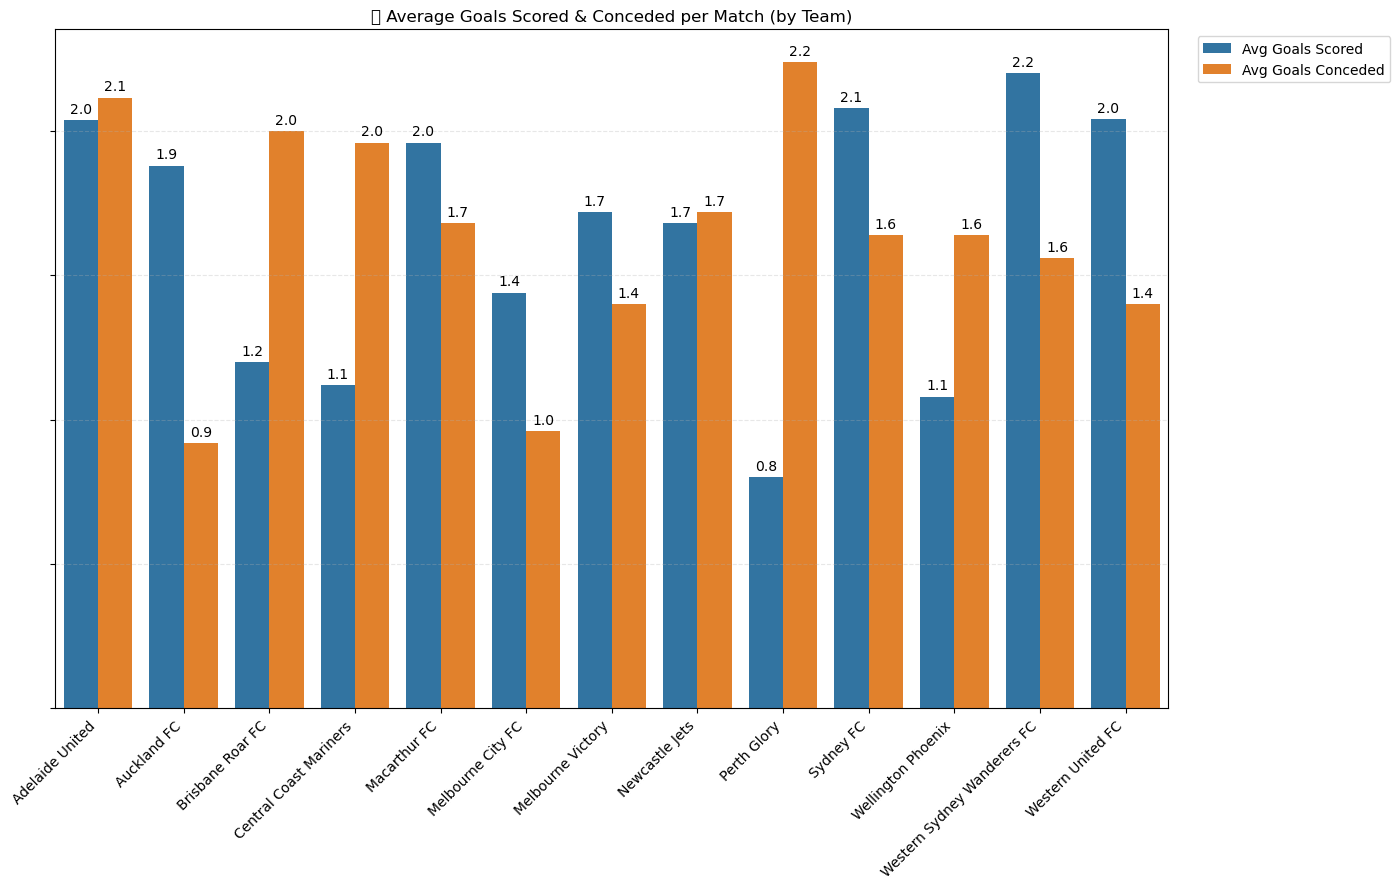

In [55]:
# Plotting grouped vertical bars with data labels and adjusted legend position
plt.figure(figsize=(16, 9))
ax = sns.barplot(data=df_melted, x='Team', y='Average Goals', hue='Metric')

# Add data labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', label_type='edge', padding=3)

# Keep x-axis labels (team names)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Remove y-axis tick labels
ax.set_yticklabels([])

# Adjust legend to be outside top-right
plt.legend(title='', loc='upper left', bbox_to_anchor=(1.02, 1))

plt.title("⚽ Average Goals Scored & Conceded per Match (by Team)")
plt.xlabel("")
plt.ylabel("")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout(rect=[0, 0, 0.88, 1])  # Make space on the_


In [59]:
#3
#Match Outcomes by Team

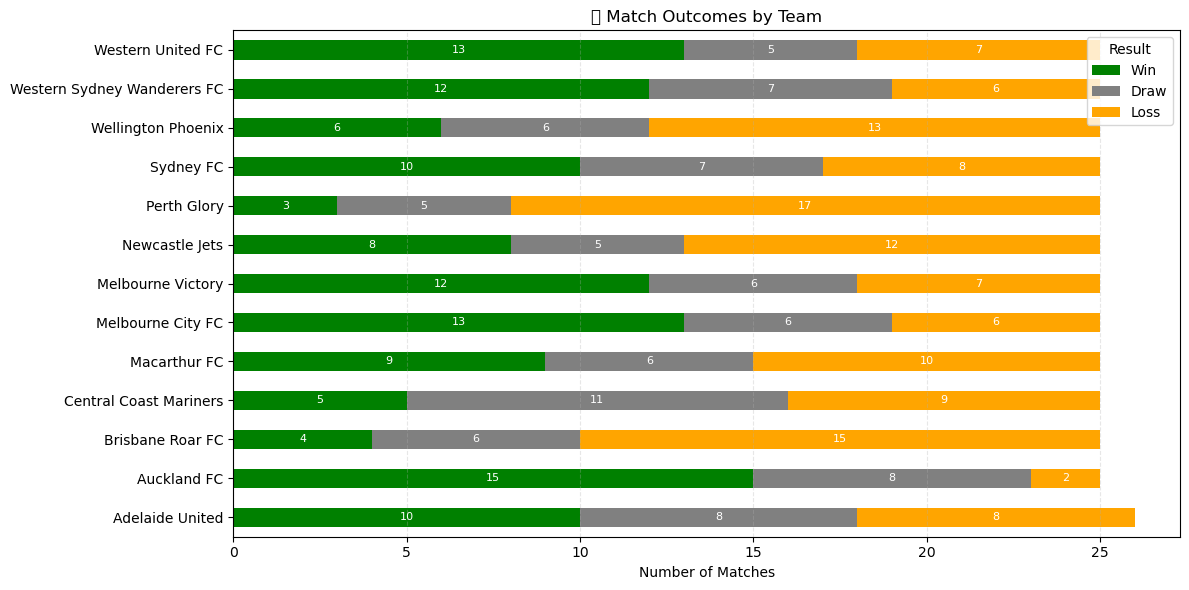

In [61]:
results = []

for _, row in df.iterrows():
    score_a, score_b = int(row['Team A Score']), int(row['Team B Score'])
    if score_a > score_b:
        results.append((row['Team A'], 'Win'))
        results.append((row['Team B'], 'Loss'))
    elif score_a < score_b:
        results.append((row['Team A'], 'Loss'))
        results.append((row['Team B'], 'Win'))
    else:
        results.append((row['Team A'], 'Draw'))
        results.append((row['Team B'], 'Draw'))

results_df = pd.DataFrame(results, columns=['Team', 'Result'])

# Count W/D/L per team
result_counts = results_df.groupby(['Team', 'Result']).size().reset_index(name='Count')

# Pivot for plotting
result_pivot = result_counts.pivot(index='Team', columns='Result', values='Count').fillna(0).astype(int)

# Plot
colors = {'Win': 'green', 'Draw': 'grey', 'Loss': 'orange'}
result_pivot = result_pivot[['Win', 'Draw', 'Loss']]  # keep order

result_pivot.plot(kind='barh', stacked=True, figsize=(12, 6), color=[colors[c] for c in result_pivot.columns])

plt.title("📊 Match Outcomes by Team")
plt.xlabel("Number of Matches")
plt.ylabel("")
plt.xticks(rotation=0)
plt.grid(axis='x', linestyle='--', alpha=0.3)

# Add data labels
for i, (idx, row) in enumerate(result_pivot.iterrows()):
    total = 0
    for j, val in enumerate(row):
        plt.text(x=total + val/2, y=i, s=str(val), va='center', ha='center', color='white', fontsize=8)
        total += val

plt.tight_layout()
plt.show()


#3
##Avg Goal Difference: Home vs Away

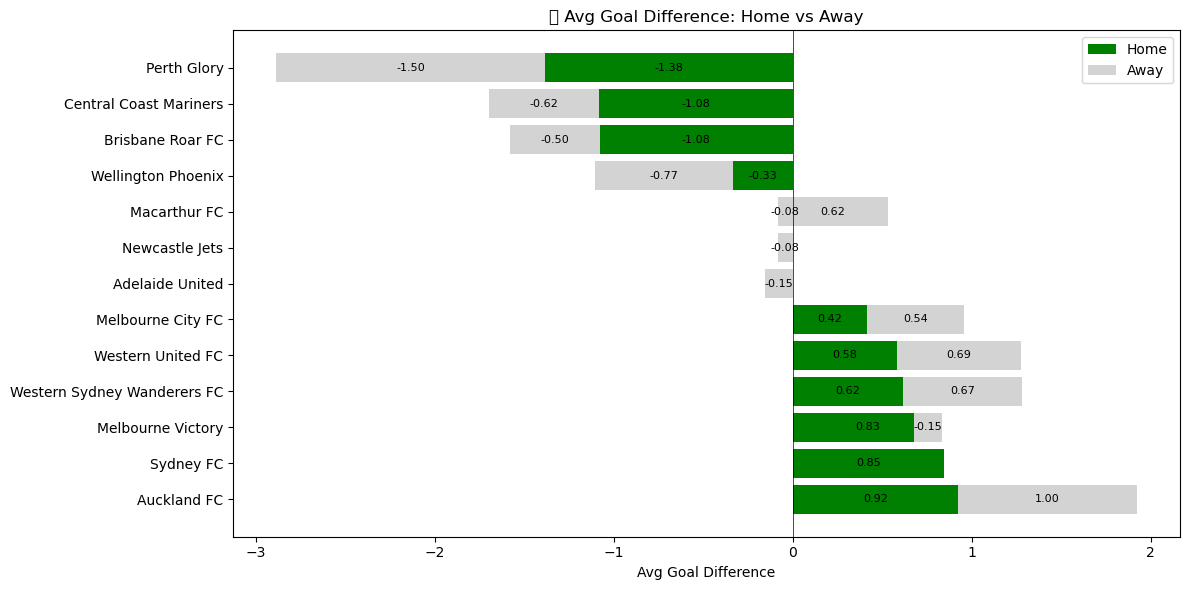

In [63]:
# Compute goal difference for home and away
home_df = df[['Team A', 'Team A Score', 'Team B Score']].copy()
home_df['Venue'] = 'Home'
home_df['GD'] = home_df['Team A Score'].astype(int) - home_df['Team B Score'].astype(int)
home_df = home_df.rename(columns={'Team A': 'Team'})

away_df = df[['Team B', 'Team B Score', 'Team A Score']].copy()
away_df['Venue'] = 'Away'
away_df['GD'] = away_df['Team B Score'].astype(int) - away_df['Team A Score'].astype(int)
away_df = away_df.rename(columns={'Team B': 'Team'})

gd_df = pd.concat([home_df[['Team', 'Venue', 'GD']], away_df[['Team', 'Venue', 'GD']]])

# Average GD
avg_gd = gd_df.groupby(['Team', 'Venue'])['GD'].mean().reset_index()

# Pivot
gd_pivot = avg_gd.pivot(index='Team', columns='Venue', values='GD').fillna(0)

# Plot
gd_pivot = gd_pivot.sort_values('Home', ascending=False)

plt.figure(figsize=(12, 6))
bar1 = plt.barh(gd_pivot.index, gd_pivot['Home'], color='green', label='Home')
bar2 = plt.barh(gd_pivot.index, gd_pivot['Away'], left=gd_pivot['Home'], color='lightgrey', label='Away')
plt.axvline(0, color='black', linewidth=0.5)

plt.title("🏠 Avg Goal Difference: Home vs Away")
plt.xlabel("Avg Goal Difference")
plt.ylabel("")
plt.legend()

# Add data labels
for bars, col in zip([bar1, bar2], ['Home', 'Away']):
    for bar in bars:
        width = bar.get_width()
        if abs(width) > 0.05:
            plt.text(bar.get_x() + width/2, bar.get_y() + bar.get_height()/2,
                     f'{width:.2f}', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()


In [80]:
gd_df

,Team,Venue,GD
0,Central Coast Mariners,Home,0
1,Auckland FC,Home,2
2,Newcastle Jets,Home,-1
3,Western Sydney Wanderers FC,Home,-1
4,Wellington Phoenix,Home,0
...,...,...,...
158,Wellington Phoenix,Away,-1
159,Western Sydney Wanderers FC,Away,1
160,Adelaide United,Away,0
161,Perth Glory,Away,-1


### 5

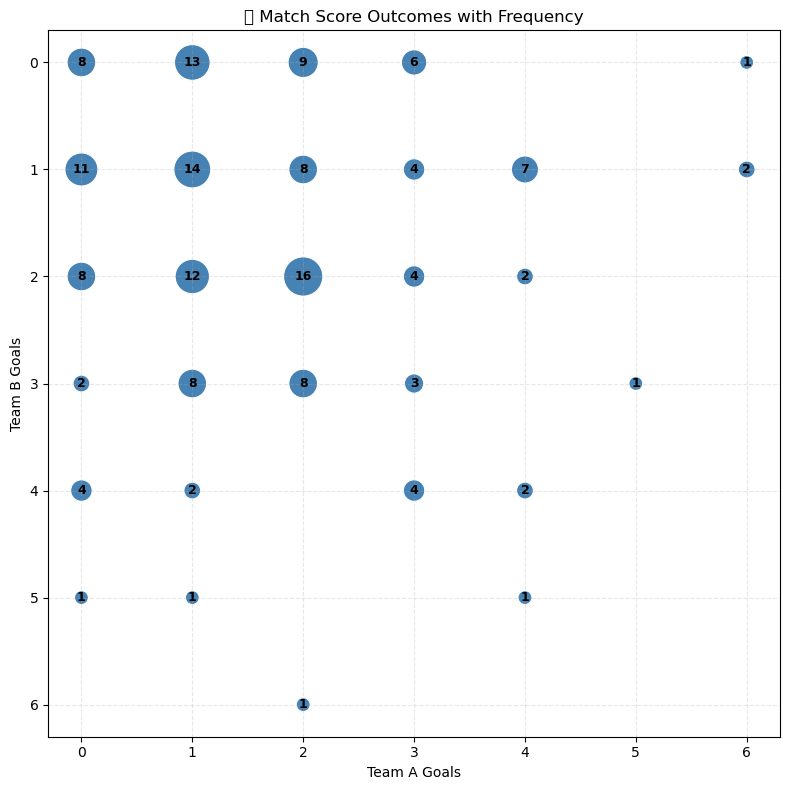

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Count how many times each score pair appears
score_counts = df.groupby(['Team A Score', 'Team B Score']).size().reset_index(name='Count')

# Plot
plt.figure(figsize=(8, 8))
sns.scatterplot(data=score_counts, x='Team A Score', y='Team B Score', size='Count', sizes=(100, 800), legend=False, color='steelblue')

# Add data labels
for _, row in score_counts.iterrows():
    plt.text(row['Team A Score'], row['Team B Score'], str(row['Count']),
             color='black', ha='center', va='center', fontsize=9, weight='bold')

plt.title("⚽ Match Score Outcomes with Frequency")
plt.xlabel("Team A Goals")
plt.ylabel("Team B Goals")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [76]:
#### score_counts
# df.groupby(['Team A Score', 'Team B Score']).size()

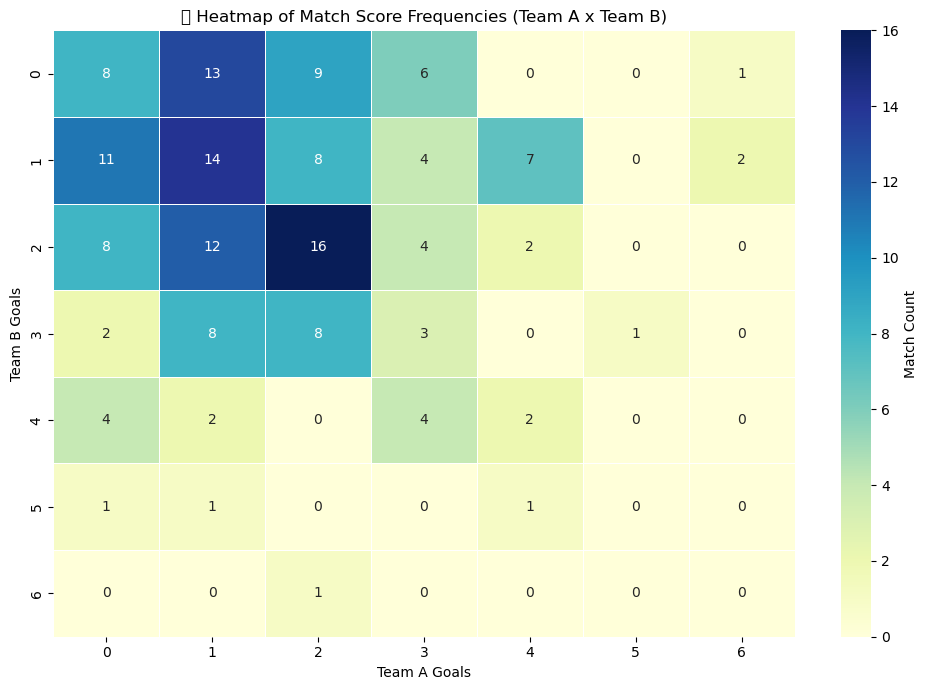

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a pivot table counting frequency of each (Team A Score, Team B Score) pair
score_matrix = df.pivot_table(index='Team B Score', columns='Team A Score', aggfunc='size', fill_value=0)

# Plot heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(score_matrix, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5, cbar_kws={'label': 'Match Count'})

plt.title("🔥 Heatmap of Match Score Frequencies (Team A x Team B)")
plt.xlabel("Team A Goals")
plt.ylabel("Team B Goals")
plt.tight_layout()
plt.show()